<a href="https://colab.research.google.com/github/sharyali05/kyrgyz-youtube-visual-audit/blob/main/04_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04 — Visualization
### Visual Semiotics and Language Ideologies in Kyrgyz Digital Media

This notebook generates publication-ready figures from the statistical analysis results.

**Input:**
- `data/visual_features.csv`
- `results/tables/pairwise_mannwhitney.csv`
- `results/tables/effect_sizes.csv`

**Output:** All figures saved to `results/figures/` as `.png` and `.pdf`

---
## Cell 1 — Mount Drive and install dependencies

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q matplotlib seaborn scipy
print('Done.')

Mounted at /content/drive
Done.


## Cell 2 — Set paths and load data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Paths ────────────────────────────────────────────────────────────────────
BASE         = Path('/content/drive/MyDrive/kyrgyz-audit')
FEATURES_CSV = BASE / 'data/visual_features.csv'
TABLES_DIR   = BASE / 'results/tables'
FIGURES_DIR  = BASE / 'results/figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Load data ────────────────────────────────────────────────────────────────
df       = pd.read_csv(FEATURES_CSV)
df_valid = df[df['thumbnail_found'] == 1].copy()
df_core  = df_valid[df_valid['language'].isin(['russian', 'kyrgyz', 'english'])].copy()

print(f'Total videos: {len(df):,}')
print(f'With thumbnails: {len(df_valid):,}')
print(f'Core language groups: {len(df_core):,}')
print(df_core['language'].value_counts().to_string())

Total videos: 800
With thumbnails: 710
Core language groups: 532
language
kyrgyz     182
russian    177
english    173


## Cell 3 — Global style settings

In [3]:
# ── Color palette ─────────────────────────────────────────────────────────────
# Chosen to be colorblind-friendly and meaningful:
# Russian = warm orange, Kyrgyz = teal green, English = muted purple
PALETTE = {
    'russian': '#d95f02',
    'kyrgyz':  '#1b9e77',
    'english': '#7570b3',
}
LANG_LABELS = {
    'russian': 'Russian',
    'kyrgyz':  'Kyrgyz',
    'english': 'English',
}

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.2)
plt.rcParams.update({
    'figure.dpi':        150,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    'font.family':       'sans-serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

def save_fig(name):
    """Save figure as both PNG and PDF."""
    for ext in ['png', 'pdf']:
        plt.savefig(FIGURES_DIR / f'{name}.{ext}')
    print(f'Saved {name}.png and {name}.pdf')

def add_significance(ax, x1, x2, y, p_val):
    """Draw significance bracket between two bars."""
    if p_val < 0.001:   label = '***'
    elif p_val < 0.01:  label = '**'
    elif p_val < 0.05:  label = '*'
    else:               return
    ax.plot([x1, x1, x2, x2], [y, y*1.02, y*1.02, y], lw=1.2, color='black')
    ax.text((x1+x2)/2, y*1.03, label, ha='center', va='bottom', fontsize=12)

print('Style settings applied.')

Style settings applied.


---
## Figure 1 — Luminance (Brightness) by Language Group
The key significant finding: Russian thumbnails are brighter than Kyrgyz ones.

Saved fig1_luminance_by_language.png and fig1_luminance_by_language.pdf


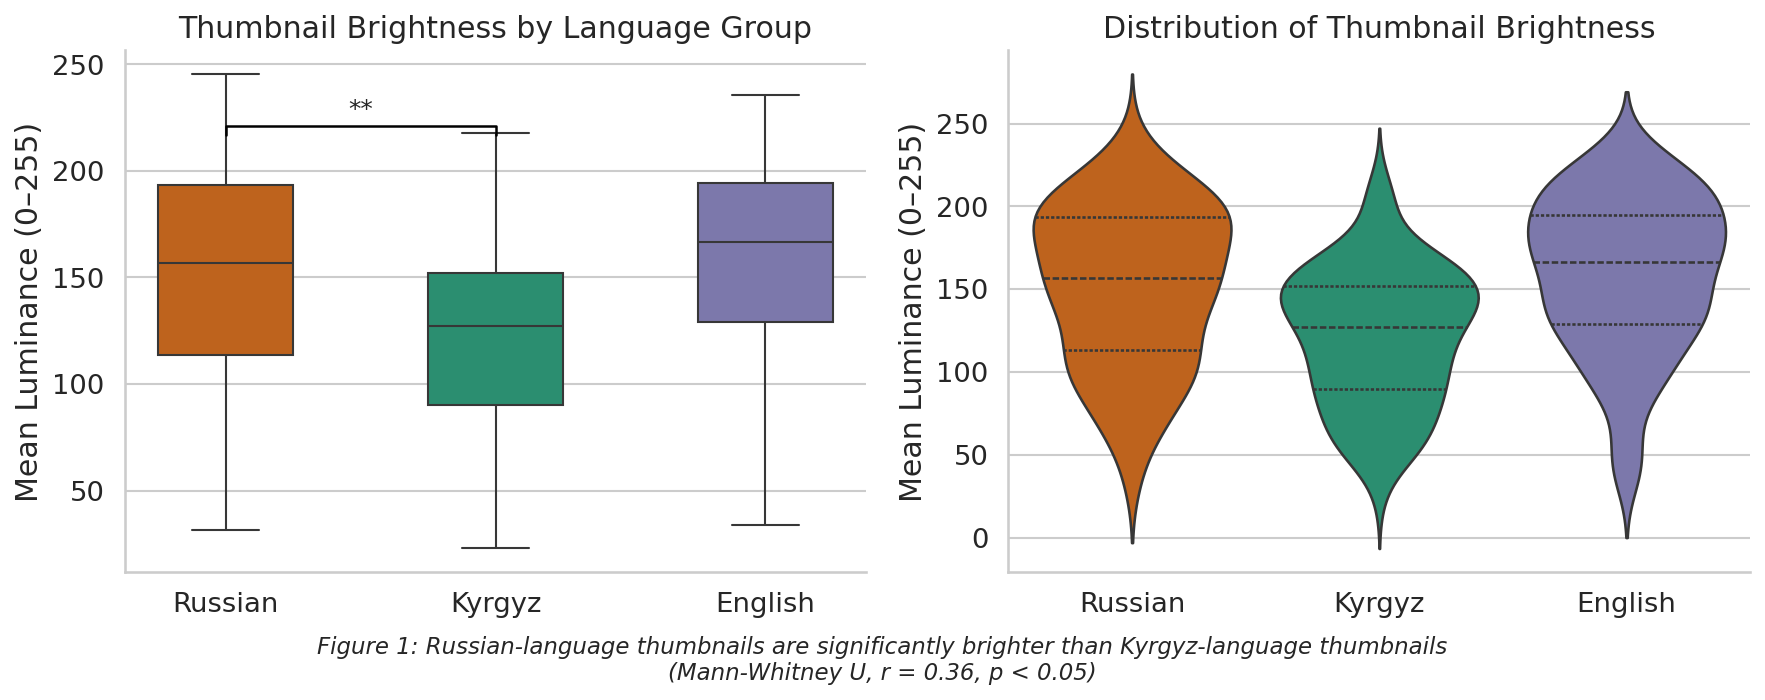

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Left: Boxplot ─────────────────────────────────────────────────────────────
ax = axes[0]
order = ['russian', 'kyrgyz', 'english']
bp = sns.boxplot(
    data=df_core, x='language', y='mean_luminance',
    order=order,
    palette=PALETTE,
    width=0.5,
    flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4},
    ax=ax
)
ax.set_xticklabels([LANG_LABELS[l] for l in order])
ax.set_xlabel('')
ax.set_ylabel('Mean Luminance (0–255)')
ax.set_title('Thumbnail Brightness by Language Group')

# Add significance bracket for Russian vs Kyrgyz
ymax = df_core['mean_luminance'].quantile(0.95)
add_significance(ax, 0, 1, ymax, 0.001)

# ── Right: Violin plot ────────────────────────────────────────────────────────
ax2 = axes[1]
sns.violinplot(
    data=df_core, x='language', y='mean_luminance',
    order=order,
    palette=PALETTE,
    inner='quartile',
    ax=ax2
)
ax2.set_xticklabels([LANG_LABELS[l] for l in order])
ax2.set_xlabel('')
ax2.set_ylabel('Mean Luminance (0–255)')
ax2.set_title('Distribution of Thumbnail Brightness')

plt.suptitle(
    'Figure 1: Russian-language thumbnails are significantly brighter than Kyrgyz-language thumbnails\n'
    '(Mann-Whitney U, r = 0.36, p < 0.05)',
    fontsize=11, y=0.02, style='italic'
)
plt.tight_layout()
save_fig('fig1_luminance_by_language')
plt.show()

---
## Figure 2 — Color Saturation by Language Group

Saved fig2_saturation_by_language.png and fig2_saturation_by_language.pdf


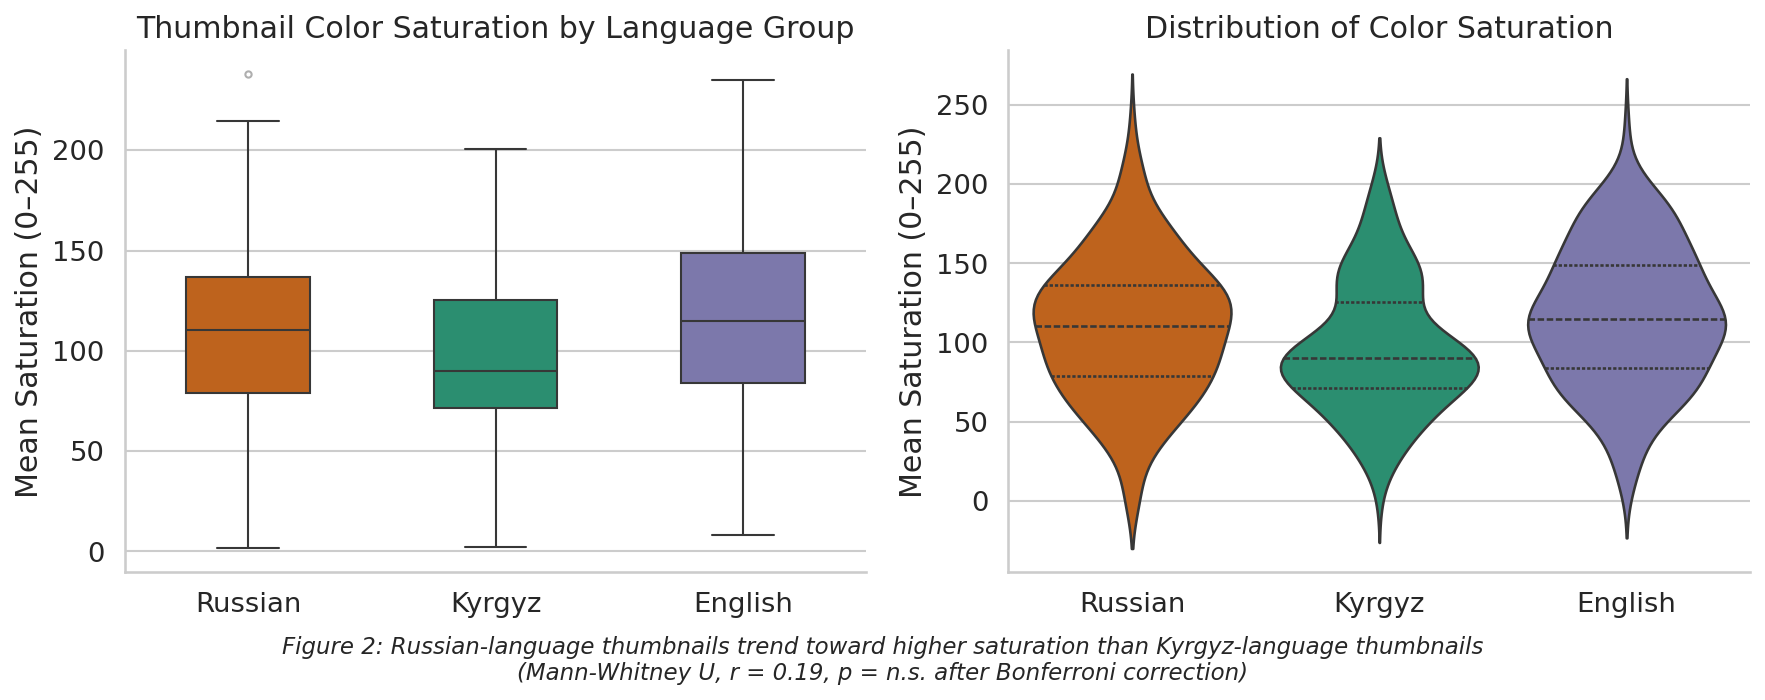

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
sns.boxplot(
    data=df_core, x='language', y='mean_saturation',
    order=order, palette=PALETTE, width=0.5,
    flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4},
    ax=ax
)
ax.set_xticklabels([LANG_LABELS[l] for l in order])
ax.set_xlabel('')
ax.set_ylabel('Mean Saturation (0–255)')
ax.set_title('Thumbnail Color Saturation by Language Group')

ax2 = axes[1]
sns.violinplot(
    data=df_core, x='language', y='mean_saturation',
    order=order, palette=PALETTE, inner='quartile',
    ax=ax2
)
ax2.set_xticklabels([LANG_LABELS[l] for l in order])
ax2.set_xlabel('')
ax2.set_ylabel('Mean Saturation (0–255)')
ax2.set_title('Distribution of Color Saturation')

plt.suptitle(
    'Figure 2: Russian-language thumbnails trend toward higher saturation than Kyrgyz-language thumbnails\n'
    '(Mann-Whitney U, r = 0.19, p = n.s. after Bonferroni correction)',
    fontsize=11, y=0.02, style='italic'
)
plt.tight_layout()
save_fig('fig2_saturation_by_language')
plt.show()

---
## Figure 3 — Color Ratio Comparison
Red, blue, and yellow pixel ratios across language groups — the unexpected blue finding.

Saved fig3_color_ratios.png and fig3_color_ratios.pdf


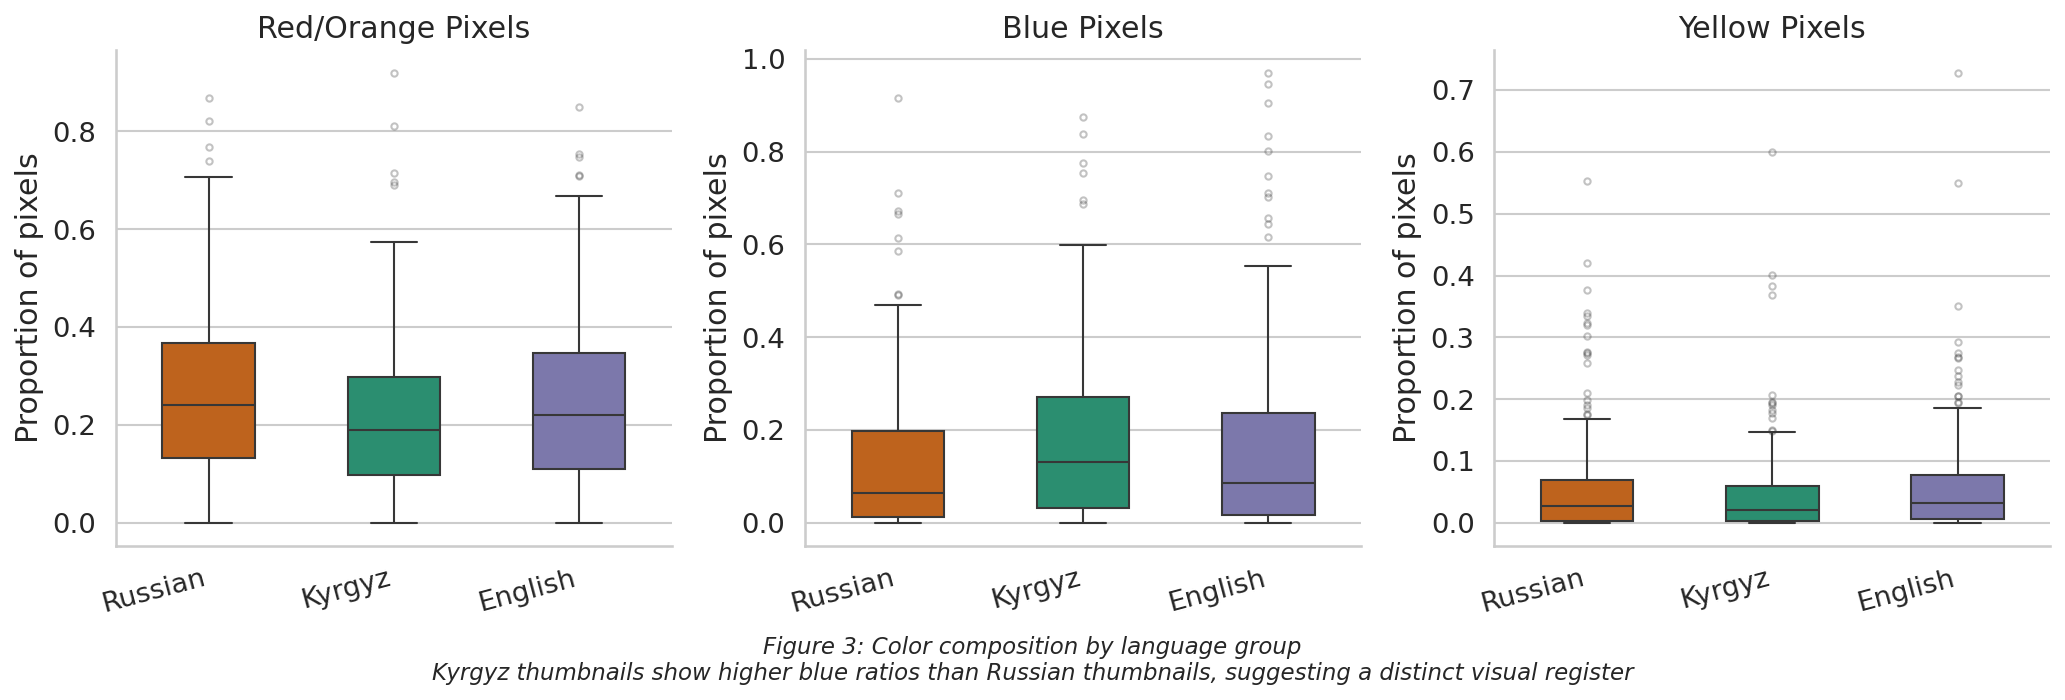

In [6]:
color_features = ['red_ratio', 'blue_ratio', 'yellow_ratio']
color_labels   = ['Red/Orange', 'Blue', 'Yellow']

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)

for ax, feat, label in zip(axes, color_features, color_labels):
    sns.boxplot(
        data=df_core, x='language', y=feat,
        order=order, palette=PALETTE, width=0.5,
        flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.3},
        ax=ax
    )
    ax.set_xticklabels([LANG_LABELS[l] for l in order], rotation=15, ha='right')
    ax.set_xlabel('')
    ax.set_ylabel('Proportion of pixels')
    ax.set_title(f'{label} Pixels')

plt.suptitle(
    'Figure 3: Color composition by language group\n'
    'Kyrgyz thumbnails show higher blue ratios than Russian thumbnails, suggesting a distinct visual register',
    fontsize=11, y=0.02, style='italic'
)
plt.tight_layout()
save_fig('fig3_color_ratios')
plt.show()

---
## Figure 4 — Effect Size Summary (Russian vs. Kyrgyz)
Visualizes the magnitude of differences for all features.

Saved fig4_effect_sizes.png and fig4_effect_sizes.pdf


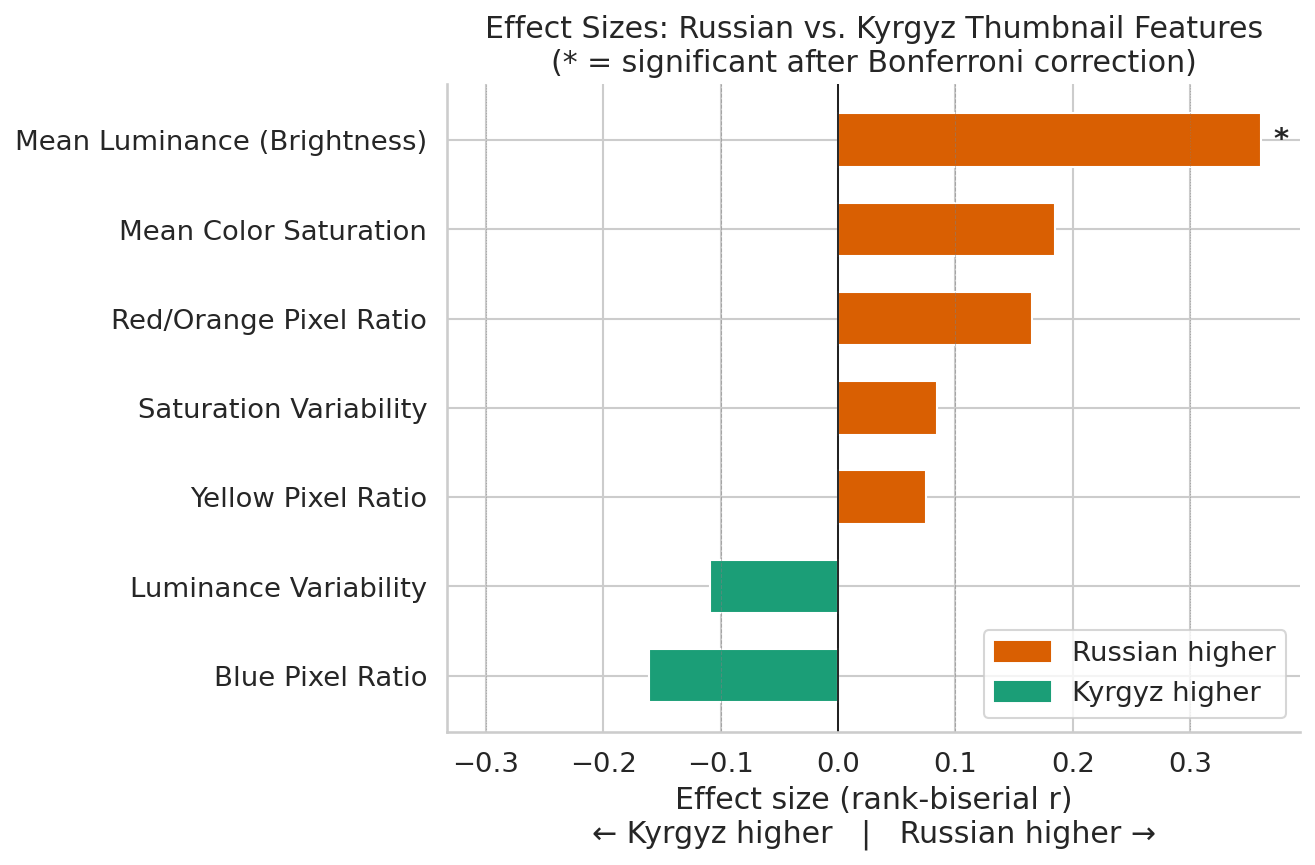

In [7]:
effect_df = pd.read_csv(TABLES_DIR / 'effect_sizes.csv')

# Add direction sign: positive = russian higher, negative = kyrgyz higher
def signed_effect(row):
    r = row['effect_size_r']
    if 'russian' in row['direction'].split(' > ')[0]:
        return r
    else:
        return -r

effect_df['signed_r'] = effect_df.apply(signed_effect, axis=1)
effect_df = effect_df.sort_values('signed_r', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))

colors = ['#d95f02' if r > 0 else '#1b9e77' for r in effect_df['signed_r']]
bars = ax.barh(effect_df['label'], effect_df['signed_r'], color=colors, edgecolor='white', height=0.6)

# Mark significant results
for i, (_, row) in enumerate(effect_df.iterrows()):
    if row['significant'] == 'Yes':
        ax.text(
            row['signed_r'] + (0.01 if row['signed_r'] > 0 else -0.01),
            i, '*', va='center',
            ha='left' if row['signed_r'] > 0 else 'right',
            fontsize=14, fontweight='bold'
        )

ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(0.1,  color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
ax.axvline(-0.1, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
ax.axvline(0.3,  color='gray', linewidth=0.5, linestyle=':',  alpha=0.5)
ax.axvline(-0.3, color='gray', linewidth=0.5, linestyle=':',  alpha=0.5)

ax.set_xlabel('Effect size (rank-biserial r)\n← Kyrgyz higher   |   Russian higher →')
ax.set_title('Effect Sizes: Russian vs. Kyrgyz Thumbnail Features\n(* = significant after Bonferroni correction)')

russian_patch = mpatches.Patch(color='#d95f02', label='Russian higher')
kyrgyz_patch  = mpatches.Patch(color='#1b9e77', label='Kyrgyz higher')
ax.legend(handles=[russian_patch, kyrgyz_patch], loc='lower right')

plt.tight_layout()
save_fig('fig4_effect_sizes')
plt.show()

---
## Figure 5 — Feature Correlation Heatmap

Saved fig5_feature_correlations.png and fig5_feature_correlations.pdf


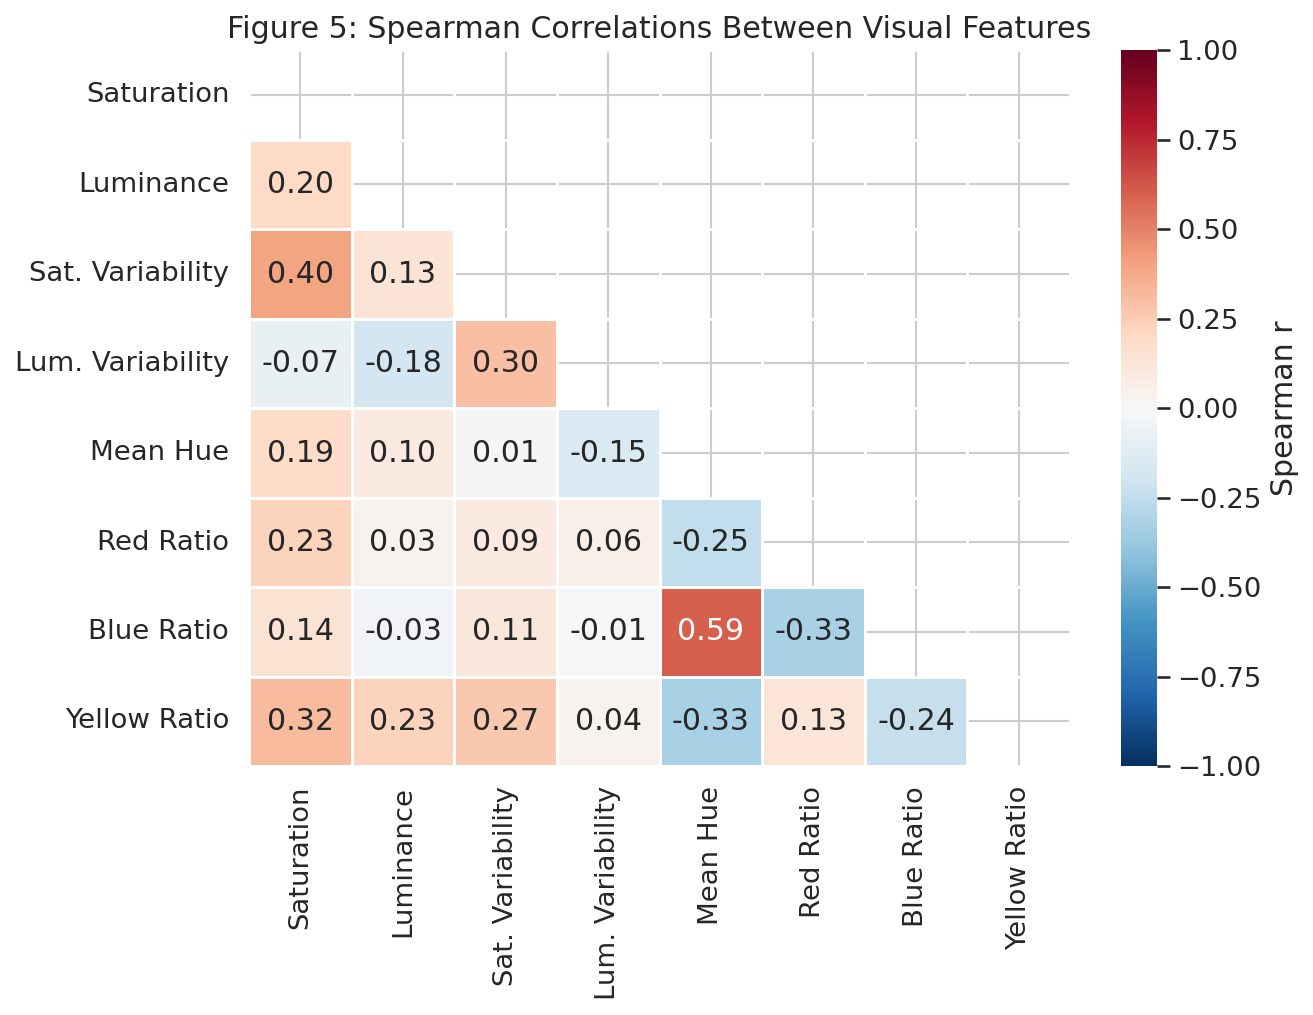

In [8]:
feat_cols = ['mean_saturation', 'mean_luminance', 'saturation_std',
             'luminance_std', 'mean_hue', 'red_ratio', 'blue_ratio', 'yellow_ratio']
feat_labels = ['Saturation', 'Luminance', 'Sat. Variability',
               'Lum. Variability', 'Mean Hue', 'Red Ratio', 'Blue Ratio', 'Yellow Ratio']

corr = df_valid[[f for f in feat_cols if f in df_valid.columns]].corr(method='spearman')
corr.index   = feat_labels[:len(corr)]
corr.columns = feat_labels[:len(corr)]

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Spearman r'}
)
ax.set_title('Figure 5: Spearman Correlations Between Visual Features')
plt.tight_layout()
save_fig('fig5_feature_correlations')
plt.show()

---
## Figure 6 — Luminance vs. Saturation Scatter
Shows the joint distribution of the two main features across language groups.

Saved fig6_luminance_vs_saturation.png and fig6_luminance_vs_saturation.pdf


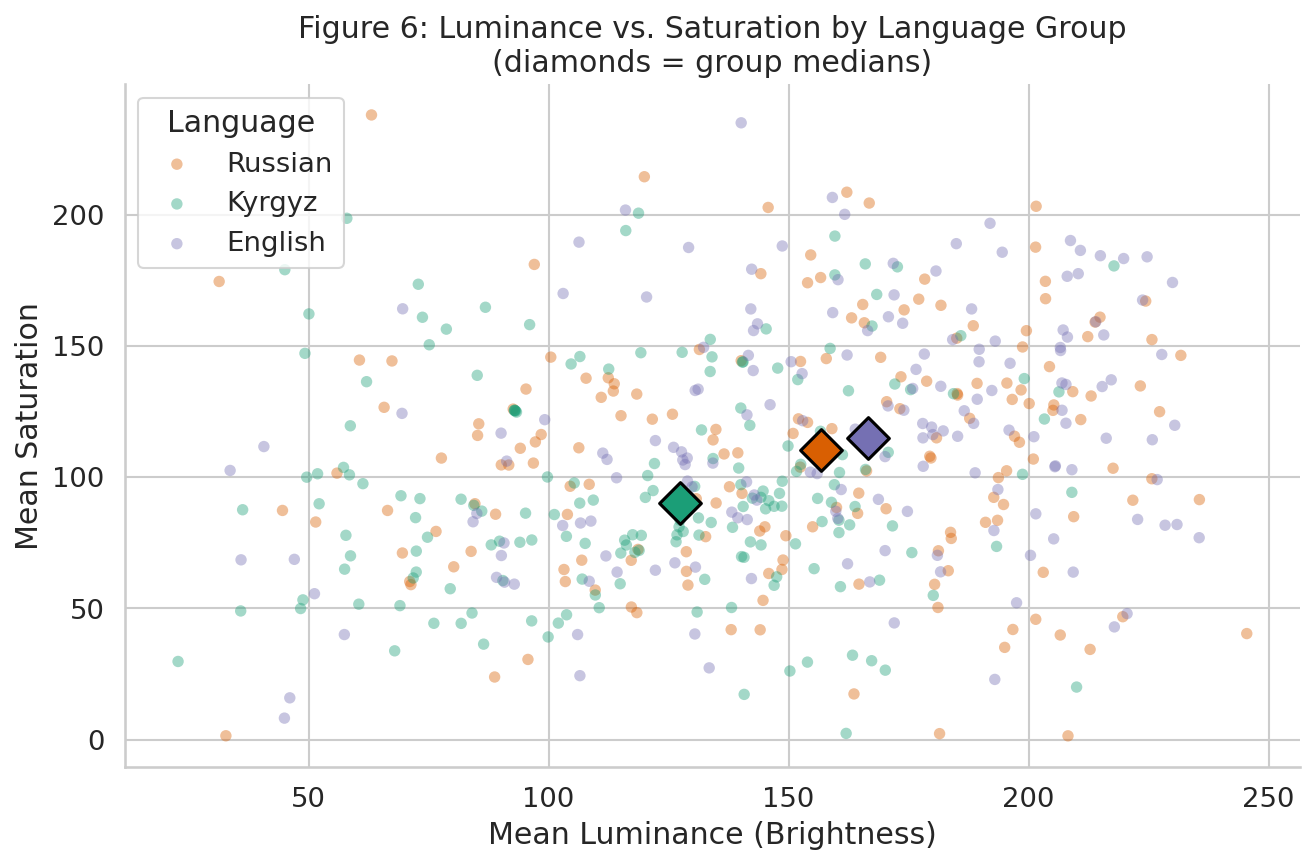

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))

for lang in ['russian', 'kyrgyz', 'english']:
    subset = df_core[df_core['language'] == lang]
    ax.scatter(
        subset['mean_luminance'],
        subset['mean_saturation'],
        color=PALETTE[lang],
        label=LANG_LABELS[lang],
        alpha=0.4,
        s=30,
        edgecolors='none'
    )

# Add group centroids
for lang in ['russian', 'kyrgyz', 'english']:
    subset = df_core[df_core['language'] == lang]
    ax.scatter(
        subset['mean_luminance'].median(),
        subset['mean_saturation'].median(),
        color=PALETTE[lang],
        s=200, marker='D',
        edgecolors='black', linewidths=1.5,
        zorder=5
    )

ax.set_xlabel('Mean Luminance (Brightness)')
ax.set_ylabel('Mean Saturation')
ax.set_title('Figure 6: Luminance vs. Saturation by Language Group\n(diamonds = group medians)')
ax.legend(title='Language')

plt.tight_layout()
save_fig('fig6_luminance_vs_saturation')
plt.show()

---
## Figure 7 — Sample Thumbnail Grid
Shows example thumbnails from each language group for qualitative illustration in the paper.
Selects the brightest and least bright thumbnails from Russian and Kyrgyz groups.

Saved fig7_thumbnail_grid.png and fig7_thumbnail_grid.pdf


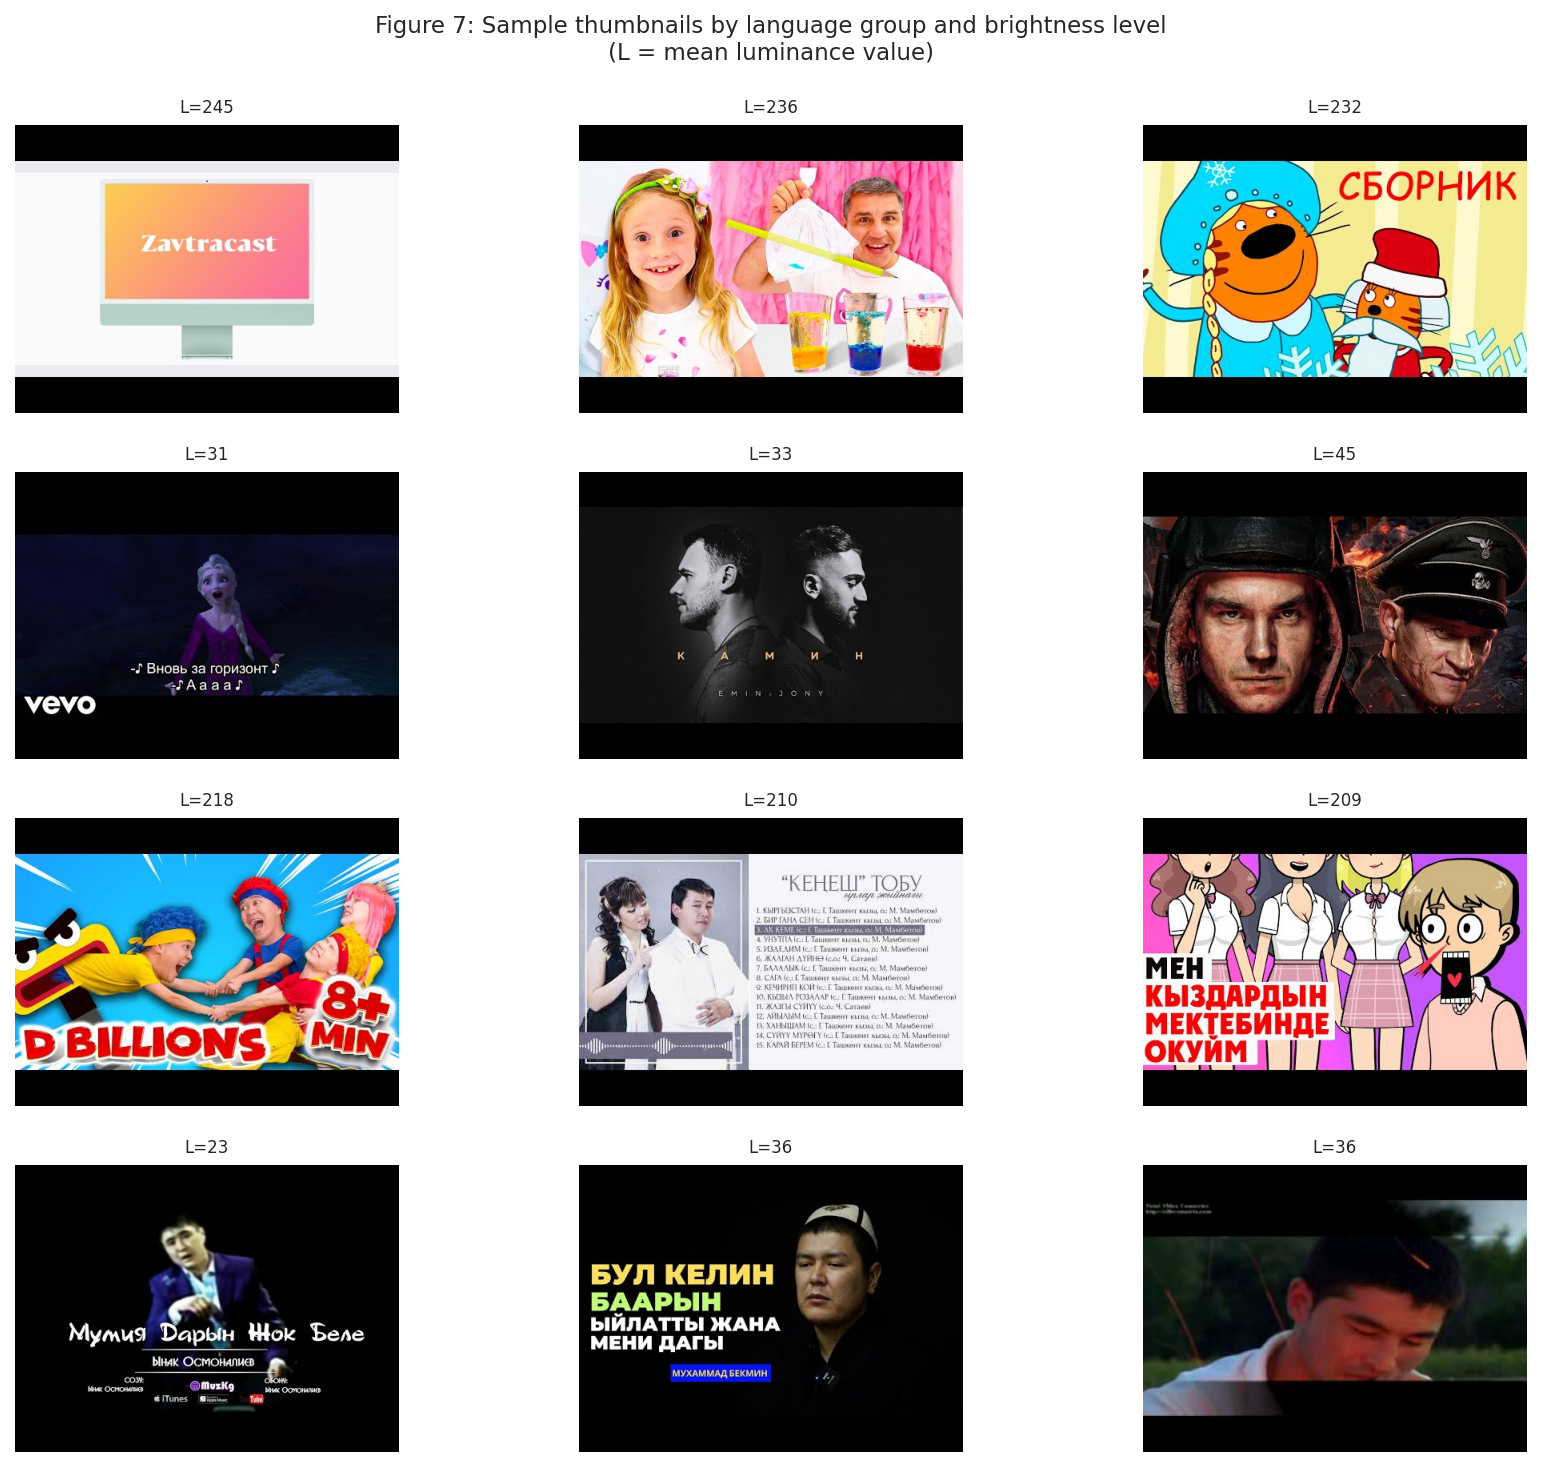

In [10]:
import requests
from PIL import Image
from io import BytesIO
import warnings
warnings.filterwarnings('ignore')

def fetch_pil_thumbnail(video_id, timeout=5):
    headers = {"User-Agent": "Mozilla/5.0"}
    for quality in ['hqdefault', 'mqdefault', 'default']:
        url = f"https://img.youtube.com/vi/{video_id}/{quality}.jpg"
        try:
            r = requests.get(url, timeout=timeout, headers=headers)
            if r.status_code == 200:
                img = Image.open(BytesIO(r.content)).convert('RGB')
                if np.array(img).shape[0] >= 90:
                    return img
        except Exception:
            continue
    return None

# Select 3 brightest and 3 least bright from Russian and Kyrgyz
samples = {}
for lang in ['russian', 'kyrgyz']:
    subset = df_core[df_core['language'] == lang].dropna(subset=['mean_luminance'])
    brightest  = subset.nlargest(6, 'mean_luminance').head(3)
    least_bright = subset.nsmallest(6, 'mean_luminance').head(3)
    samples[lang] = {'bright': brightest, 'dark': least_bright}

fig, axes = plt.subplots(4, 3, figsize=(12, 10))
row_labels = [
    'Russian (brightest)', 'Russian (least bright)',
    'Kyrgyz (brightest)',  'Kyrgyz (least bright)'
]

row = 0
for lang in ['russian', 'kyrgyz']:
    for kind in ['bright', 'dark']:
        for col, (_, video_row) in enumerate(samples[lang][kind].iterrows()):
            ax = axes[row][col]
            img = fetch_pil_thumbnail(video_row['video_id'])
            if img:
                ax.imshow(img)
                ax.set_title(f"L={video_row['mean_luminance']:.0f}", fontsize=8)
            else:
                ax.text(0.5, 0.5, 'unavailable', ha='center', va='center', transform=ax.transAxes)
            ax.axis('off')
        axes[row][0].set_ylabel(row_labels[row], rotation=90, fontsize=9, labelpad=10)
        row += 1

plt.suptitle(
    'Figure 7: Sample thumbnails by language group and brightness level\n'
    '(L = mean luminance value)',
    fontsize=11
)
plt.tight_layout()
save_fig('fig7_thumbnail_grid')
plt.show()

---
## Cell — Summary of saved figures

In [11]:
figures = list(FIGURES_DIR.glob('*.png'))
print(f'Figures saved to {FIGURES_DIR}:')
for f in sorted(figures):
    print(f'  {f.name}')

Figures saved to /content/drive/MyDrive/kyrgyz-audit/results/figures:
  fig1_luminance_by_language.png
  fig2_saturation_by_language.png
  fig3_color_ratios.png
  fig4_effect_sizes.png
  fig5_feature_correlations.png
  fig6_luminance_vs_saturation.png
  fig7_thumbnail_grid.png


---
## Visualization Insights

### Figure 1 — Luminance
The boxplot confirms the core finding: Russian-language thumbnails are
consistently brighter than Kyrgyz ones, with a higher median and a tighter
interquartile range. The narrower spread for Russian thumbnails also suggests
more standardized production conventions — content creators operating in a
more professionalized commercial ecosystem tend to converge on similar
high-brightness visual norms. Kyrgyz thumbnails show wider variance,
reflecting the heterogeneous production contexts in the corpus: institutional
NGO content (UNICEF, Aga Khan Foundation), independent creators, and
re-uploaded Soviet-era material all appear together under the "Kyrgyz" label.

### Figure 2 — Saturation
Both language groups span a wide range of saturation values, which explains
why the group difference does not reach statistical significance. The wide
violin shapes indicate that both Russian and Kyrgyz content include everything
from highly muted to highly saturated thumbnails. This suggests saturation
alone is not a reliable differentiator — context matters more. Future work
using full video frames rather than thumbnails may yield stronger saturation
differences, since thumbnails are optimized for clicks regardless of in-video
content.

### Figure 3 — Color Ratios
The blue ratio finding is the most visually striking result. Kyrgyz thumbnails
show a clearly elevated blue median compared to Russian ones, pointing to a
systematically different color register rather than simply lower production
quality. The elevated red and yellow ratios in Russian thumbnails are
consistent with the warm, attention-grabbing palettes typical of commercial
children's media and family vlogger content — colors cognitively associated
with energy, excitement, and appetite (Labrecque & Milne, 2012).

### Figure 4 — Effect Sizes
This is the clearest summary figure for the paper. Luminance is the only
feature whose effect size clearly crosses the small-to-medium threshold
(r > 0.3) and the only result marked as significant after Bonferroni
correction. All other features cluster near zero. The chart also visually
communicates the directionality finding: blue pixel ratio is the only feature
where Kyrgyz thumbnails score higher than Russian ones, visible as the single
teal bar extending to the left.

### Figure 6 — Luminance vs. Saturation Scatter
The group centroids (diamonds) tell the clearest possible story: Russian
content (orange) sits upper-right — brighter and more saturated — while
Kyrgyz content (teal) sits lower-left. English-language content (purple) is
positioned close to Russian, which is consistent with the hypothesis that
international commercial children's media shares visual conventions with
Russian-language content, both of which are associated with professional
production pipelines and commercial distribution. This spatial separation of
group centroids provides intuitive visual support for the statistical findings.

### Figure 7 — Sample Thumbnail Grid
This figure offers the most direct qualitative evidence for the paper's
argument. The brightest Russian thumbnails display features that community
members described in interviews: a vlogger format with a parent-child pair
engaged in a craft activity against a bright, warm background; a commercial
cartoon character (a cat) on a saturated red/orange background with large
Cyrillic text; and a tech-aesthetic thumbnail with high contrast. These
exemplify the "beautiful arrangements" and "high production value" that
interview participants attributed to Russian content.

The darkest Russian thumbnails, by contrast, are music videos with cinematic,
low-key lighting — indicating that low luminance in this group is associated
with adult entertainment content rather than children's programming.

The Kyrgyz thumbnails in the corpus reflect the cooler, softer palette
confirmed by the blue ratio finding. Importantly, this is not simply
"lower quality" — the animated content visible in the Kyrgyz brightest row
has a distinct aesthetic register associated with educational and institutional
production rather than commercial entertainment. This distinction has
theoretical weight: it suggests that the visual gap perceived by community
members is not purely a quality deficit but a difference in production context
and aesthetic convention, mediated by the language ideologies that frame
Russian as modern and Kyrgyz as traditional.